# Modéle ARIMA

Le modéle ARIMA pour AutoRegressif Integreted Moving Average est une méthode couramment utilisée pour prevoir les séries temporelles. Il combine les composante de l'autoregression(AR) et de la moyenne mobile(MA) avec une différenciation(I) pour prendre en compte les tendances et les différentes saisonalitées dans notre modéle.

Les composantes d'un modéle ARIMA sont :



1.   AR(autoregression): elle fait reférence a la regression lineaire des valeurs actuelles sur les valeurs précédentes de la serie temporelle. Il capture les effets de dépendances linéaires à partir des valeurs passées.
2.   MA(Moyenne Mobile) : elle utilise la moyenne mobile des erreurs précédentes pour modéliser la relation entre les residus et les observations actuelles de la série temporelle. Il capture les effets de dépendance entre les residus.
3.   I(différenciation): elle est utilisée pour rendre les données stationnaires en supprimant les tendances et les comportement saisonniérs. elle consiste à prendre la différence entre les observations consécutives jusqu'à obtenir une serie stationnaire.



 **Ordre du modéle ARIMA:**

 - P(Ordre AR): il spécifie le nombre de termes autoregressifs à inclure dans le modéle. Il indique combien de valeurs passées sont utilisées pour prédire la valeur actuelle.

 - d(Ordre de diofférentiation): Il indique combien de fois la série doit etre différenciée pour rendre les données stationnaires.

 - q(Ordre MA): Il spécifie le nombre de terme de la moyenne mobile a inclure dans le modéle. Il indique combien de résidu passé sont utilisé pour prédire l'observation actuelle.


## Méthodologie de Box-Jenkins du modéle ARIMA

C'est une methodologie couramment utilisée pour modéliser et prédire les séries temporelles. Elle comprend les étapes suivantes:

1.  **Identification du modéle:**
- Analyse des données: Examiner les données de la serie temporelle pour détecter les tendances, les saisonnalités et les comportements anormaux.
- Différenciation: si la série temporelle présente une tendance ou une saisonnalité, appliquer une différenciation pour rendre les données stationnaires.
- Identification des ordres: Utiliser les graphiques ACF(Auto correlation function), et PACF(fonction partielle d'autocorrelation) pour déterminer les ordres p, d et q du modéle ARIMA.

2.  **Estimation du modéle:**
Utiliser les méthodes d'estimation (telles que la méthode des moindres carrées ordinaires) pour estimer les paramétres du modéle ARIMA.

3.  **Vérification du modéle:**
- Diagnostic du modéle: vérifier si les résidus du modéle ARIMA sont les bruits blancs(c à d s'il ne présente pas de structure ou de correlation significative)

- réajustement: si le modéle ne satisfait pas les critéres de bruit blanc, ajuster les ordres du modéle ARIMA et repéter les étapes précédentes.
- validation: valider les performances du modéle en éffectuant les prédictions sur les données de validations ou en utilisant les mésures d'évaluation telles que l'erreur quadratique moyenne(RMSE), ou le critére d'akaike(AIC).

***La méthodologie de Box jenkis est itérative, ce qui signifie que les étapes d'identification, d'estimation et de vérification du modéle peuvent etre repétés plusieurs fois pour améliorer le modéle. L'objectif est de trouver le meilleur modéle ARIMA qui capture les motifs et les caractéristiques importantes de la série temporelle, et qui peut etre utilisé pour éffectuer les prédictions précises.***





# présentation de la base de donnée et chargement des données

Apple Inc. is an American multinational technology company that specializes in consumer electronics, computer software, and online services. Apple is the world's largest technology company by revenue and, since January 2021, the world's most valuable company.

## Problématique métier

Un investisseur souhaite analyser l’évolution des prix des actions d’Apple afin d’anticiper leurs variations futures.
Votre mission est d'exploiter les séries temporelles pour identifier des tendances et proposer un modèle de prévision des prix.

## description de la base de donnée
la base de donnée: Apple Stock Price que vous pouvez retrouver a cette adresse: [https://www.kaggle.com/datasets/henryshan/apple-stock-price](https://www.kaggle.com/datasets/henryshan/apple-stock-price)

Variables clés :      
- Date : Date de l'enregistrement
- Open : Prix d’ouverture
- High : Prix le plus haut de la journée
- Low : Prix le plus bas de la journée
- Close : Prix de clôture (variable cible)
- Volume : Volume d’échange





## chargement des packages et des données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('/content/AAPL (1).csv')

In [5]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600
...,...,...,...,...,...,...,...
10831,2023-11-29,190.899994,192.089996,188.970001,189.369995,189.369995,43014200
10832,2023-11-30,189.839996,190.320007,188.190002,189.949997,189.949997,48794400
10833,2023-12-01,190.330002,191.559998,189.229996,191.240005,191.240005,45679300
10834,2023-12-04,189.979996,190.050003,187.449997,189.429993,189.429993,43389500


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10836 non-null  object 
 1   Open       10836 non-null  float64
 2   High       10836 non-null  float64
 3   Low        10836 non-null  float64
 4   Close      10836 non-null  float64
 5   Adj Close  10836 non-null  float64
 6   Volume     10836 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 592.7+ KB


Ici on vois que la variable Date est une variable qualitative donc nous allons dans un premier temps transformer cette variable en variable de type datetime

In [7]:
from datetime import datetime
data['Date'] = pd.to_datetime(data['Date'], infer_datetime_format=True)


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10836 non-null  datetime64[ns]
 1   Open       10836 non-null  float64       
 2   High       10836 non-null  float64       
 3   Low        10836 non-null  float64       
 4   Close      10836 non-null  float64       
 5   Adj Close  10836 non-null  float64       
 6   Volume     10836 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 592.7 KB


In [9]:
# mettre la date en index de ma table
data.set_index('Date', inplace=True)
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600
...,...,...,...,...,...,...
2023-11-29,190.899994,192.089996,188.970001,189.369995,189.369995,43014200
2023-11-30,189.839996,190.320007,188.190002,189.949997,189.949997,48794400
2023-12-01,190.330002,191.559998,189.229996,191.240005,191.240005,45679300


In [10]:
data.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
data.duplicated().sum()

np.int64(0)

notre jeu de donnée ne contient pas de valeurs manquantes, ni de doublons.

# Etape 1: Identification du modéle

## Analyse de donnée

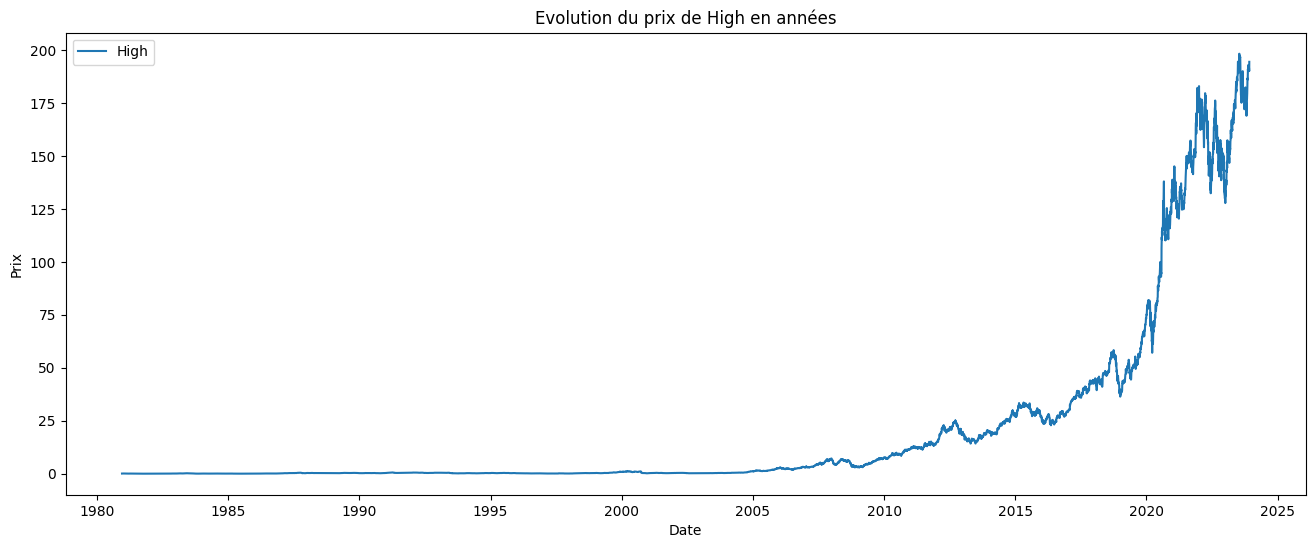

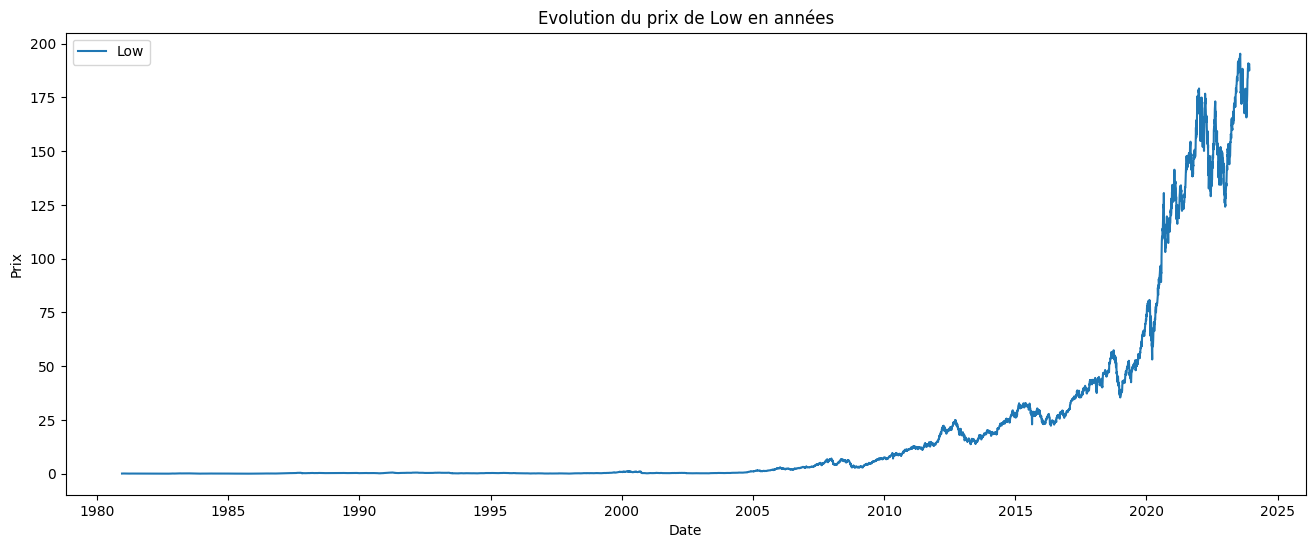

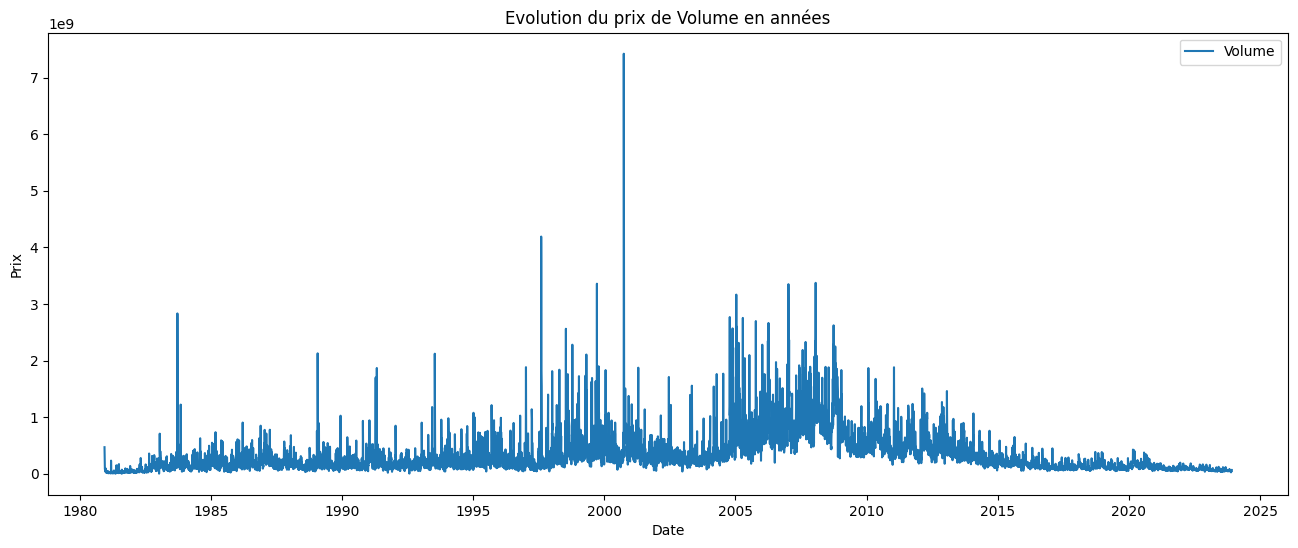

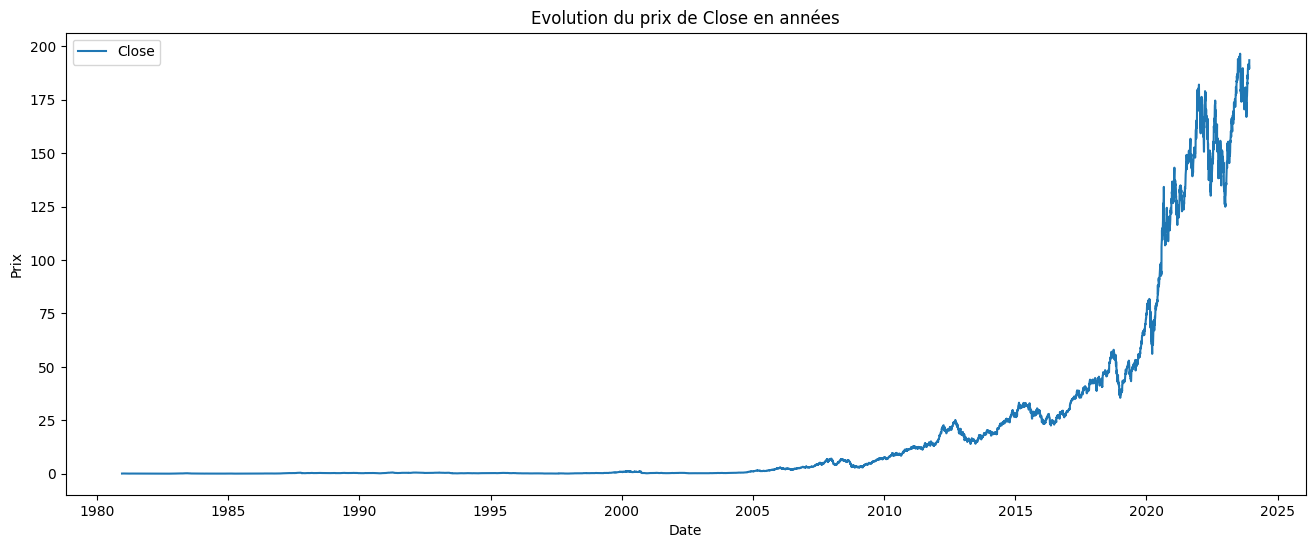

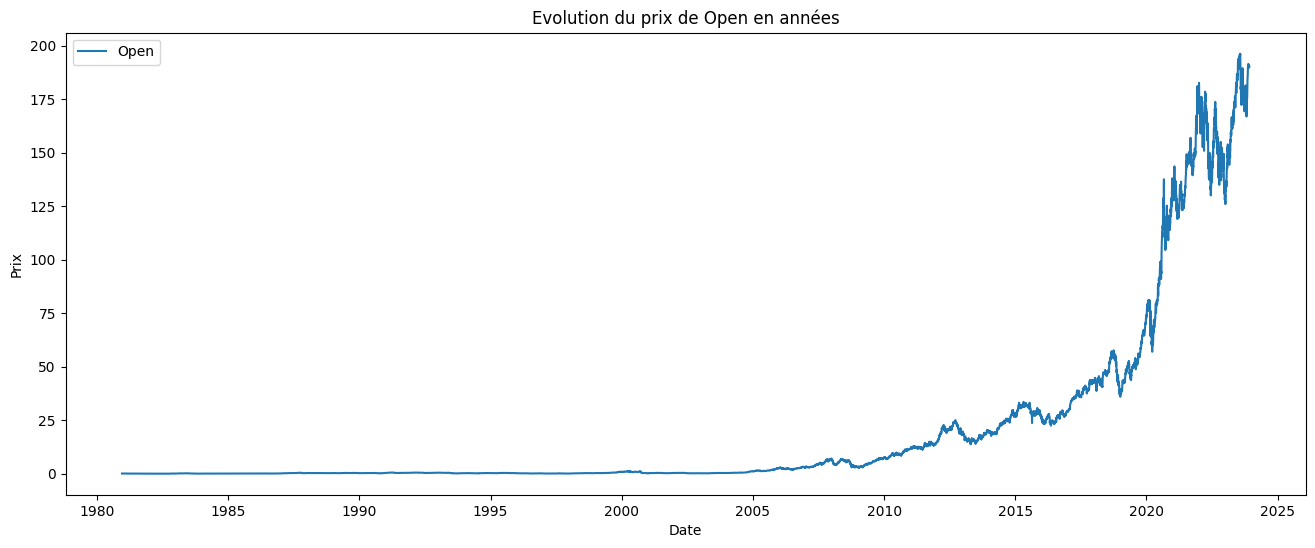

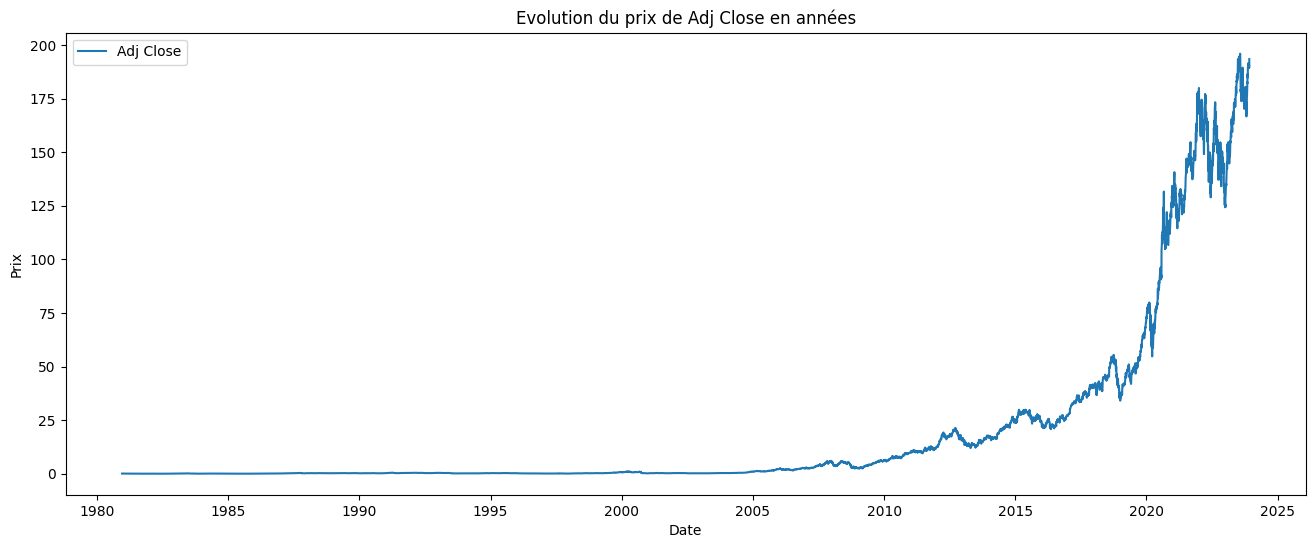

In [12]:
# créer la fonction qui va permettre de faire toute les représentations graphiques de notre série
def representation_graphique(serie):
  plt.figure(figsize=(16,6))
  plt.plot(serie.index, serie, label=serie.name)
  plt.xlabel('Date')
  plt.ylabel('Prix')
  plt.title(f'Evolution du prix de {serie.name} en années')
  plt.legend()
  plt.show()

representation_graphique(data['High'])
representation_graphique(data['Low'])
representation_graphique(data['Volume'])
representation_graphique(data['Close'])
representation_graphique(data['Open'])
representation_graphique(data['Adj Close'])

## Décomposer la série en tandances, saisonalités et résidus

pour décomposer la série temporelle en tendance, saisonarité et les residus on utilise la fonction seasonal_decompose du package statsmodels.

Nous allons maintenant générer les graphiques ACF et PACF pour la série `Close` afin d'identifier d'éventuelles saisonnalités et de déterminer les ordres appropriés pour un modèle ARIMA.

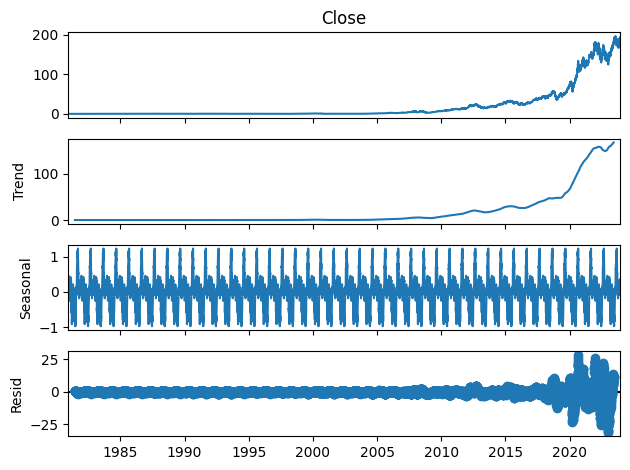

In [13]:
# Décomposer la série en tendances, saisonalité et residus
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data['Close'], model='additive', period=252)
decomposition.plot()
plt.show()

***
Interprétation
***
- Tendance : Le graphique de la tendance montre clairement une croissance soutenue et significative du prix de l'action Apple sur le long terme. On observe une augmentation générale des prix au fil des années, avec des périodes de fluctuations plus ou moins prononcées, mais la direction générale reste fortement haussière. Cela reflète la performance historique de l'entreprise.

- Saisonnalité : En utilisant une période de 252 jours (représentant une année de jours de bourse), le composant saisonnier tente de capturer les modèles récurrents au cours d'une année. Pour les données boursières quotidiennes, la saisonnalité est souvent moins prononcée ou moins 'propre' que la tendance. On peut observer des motifs récurrents, mais ils sont généralement d'une amplitude plus faible par rapport à la tendance. Cela signifie que l'effet de facteurs annuels spécifiques (comme les annonces de produits, les résultats trimestriels) est présent mais pas toujours dominant ou prévisible de manière stricte sur une base annuelle fixe.

- Résidus : Le graphique des résidus représente ce qui reste de la série après avoir soustrait la tendance et la saisonnalité. Idéalement, ces résidus devraient ressembler à un bruit blanc, c'est-à-dire des fluctuations aléatoires sans aucune structure identifiable. Pour les prix des actions, les résidus sont souvent imprévisibles et ne montrent pas de motifs clairs, ce qui est généralement un bon signe, car cela suggère que la tendance et la saisonnalité ont été relativement bien capturées. Si des structures (tendances, saisonnalités non capturées) étaient encore visibles dans les résidus, cela indiquerait que notre modèle de décomposition n'a pas entièrement expliqué les variations de la série.

## Comment déterminer la période pour `seasonal_decompose` avec `statsmodels`?

La fonction `seasonal_decompose` de `statsmodels` ne détecte pas automatiquement la période de saisonnalité. Vous devez la spécifier manuellement via le paramètre `period`.

Plusieurs méthodes peuvent vous aider à déterminer cette période :

1.  **Connaissance du domaine :** Pour les données boursières quotidiennes, une saisonnalité annuelle est souvent modélisée avec une période de **252** (le nombre moyen de jours de négociation dans une année). Si vous recherchez une saisonnalité hebdomadaire, la période serait de **7**. Pour des données mensuelles, la période serait de **12**.
2.  **Analyse visuelle des séries temporelles :** Observer le graphique de votre série temporelle peut parfois révéler des motifs répétitifs.
3.  **Fonctions d'autocorrélation (ACF) et de corrélation partielle (PACF) :** Ces graphiques sont des outils essentiels dans la méthodologie de Box-Jenkins pour identifier la saisonnalité et les ordres `p` et `q` d'un modèle ARIMA. Un pic significatif et répétitif dans l'ACF à des retards réguliers (par exemple, tous les 7, 12 ou 252 lags) peut indiquer une saisonnalité.

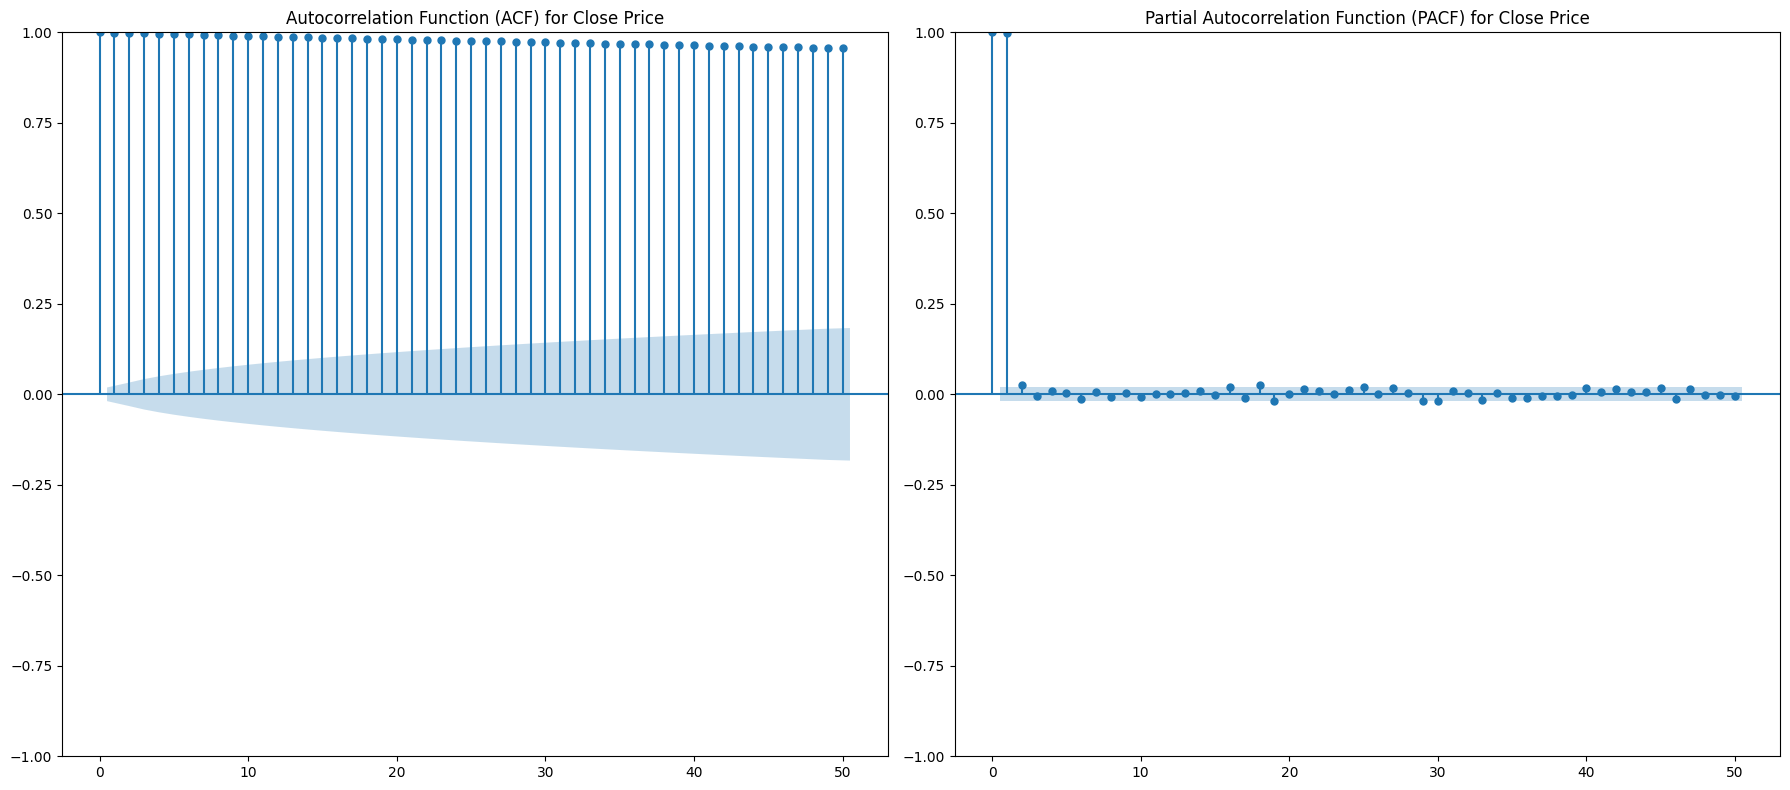

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Créer les plots ACF et PACF pour la série 'Close'
plt.figure(figsize=(18, 8))
plt.subplot(121)
plot_acf(data['Close'], lags=50, ax=plt.gca(), title='Autocorrelation Function (ACF) for Close Price')
plt.subplot(122)
plot_pacf(data['Close'], lags=50, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) for Close Price')
plt.tight_layout()
plt.show()

En examinant les graphiques ACF et PACF pour le prix close on observe:

- Une décroissance lente dans l'ACF et la PACF: les deux graphiques montrent des autocorrelations qui diminuent lentement , restant significativement élevées sur des nombreux décalages(lags). C'est une forte indication que la série n'est pas ***stationaire*** et contient probablement une tendance.
- Abscence de pics saisonniers distincts: nous n'observons pas des pics clairs et repétitifs à des décalages spécifiques(tous les 7 lags pour une saisonalité hebdomadaire ou tous les 252 lags  pour une saisonalité annuelle) qui suggére des forts motifs saisoniers.

Comme notre serie présente une tendance et non une saisonalité il serait judicieux pour nous de rendre la serie stationnaire par différenciation.

## Vérifier la stationnarité avec ADF et KPSS.

Nous allons différencier la série pour la rendre stationnaire.

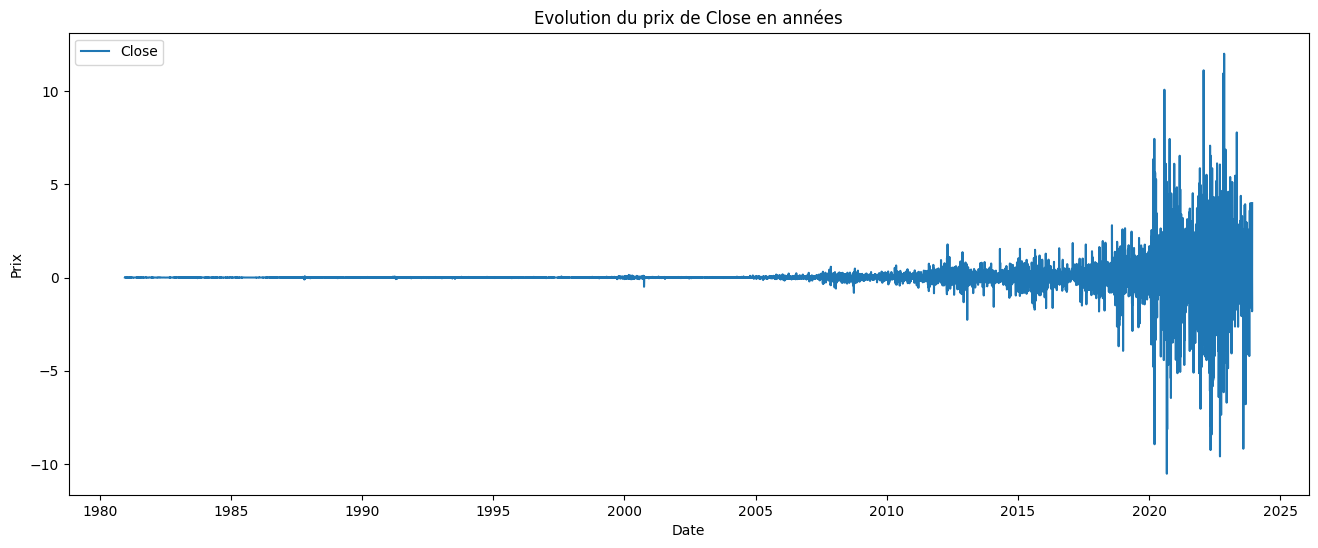

In [15]:
# différencier pour rendre la série stationnaire
data_diff = data['Close'].diff().dropna()

# affiché la serie différenciée
plt.figure(figsize=(16,6))
plt.plot(data_diff.index, data_diff, label=data_diff.name)
plt.xlabel('Date')
plt.ylabel('Prix')
plt.title(f'Evolution du prix de {data_diff.name} en années')
plt.legend()
plt.show()

après avoir appliqué une première différenciation. Voici mon interprétation :

Suppression de la Tendance : Contrairement à la série originale, cette figure montre que la tendance ascendante marquée a été supprimée. La série différenciée semble maintenant osciller autour d'une moyenne constante, proche de zéro.

Fluctuations : On observe des fluctuations plus aléatoires, sans schéma clair de croissance ou de décroissance à long terme. Cela indique que la différenciation a réussi à éliminer le composant non stationnaire lié à la tendance.

Vers la Stationnarité : Visuellement, cette série est beaucoup plus proche de la stationnarité que la série originale. Une série stationnaire est cruciale pour l'application des modèles ARIMA. Cependant, une inspection visuelle ne suffit pas; il est recommandé de confirmer la stationnarité avec des tests statistiques formels comme le test de Dickey-Fuller Augmenté (ADF) ou le test de KPSS. Ces tests nous donneront une confirmation statistique que la différenciation a bien rendu la série stationnaire.

### test de Dickey-Fuller Augmenté(ADF)

In [16]:
# mettre en place le test de Dickey-fuller augmenté
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

# Effectuer le test de Dickey-Fuller Augmenté
result = adfuller(data_diff)

# Extraire les statistiques d'intérêt
adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

# Créer une table avec les résultats
table = [
    ['Statistic', 'Value'],
    ['ADF Statistic', adf_statistic],
    ['p-value', p_value],
    ['Critical Values', critical_values],
    ['La série est elle stationnaire?', 'OUI' if p_value < 0.05 else 'Non']
]

# Afficher la table
print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))


╒═════════════════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Statistic                       │ Value                                                                                                                │
╞═════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ ADF Statistic                   │ -17.685188374273725                                                                                                  │
├─────────────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ p-value                         │ 3.5930760526820775e-30                                                                                               │
├─────────────────────────────────┼───────────────────────────────────

### test de KPSS

In [17]:
# effectuer le test de KPSS
from statsmodels.tsa.stattools import kpss

# Effectuer le test de KPSS
result = kpss(data_diff)

# Extraire les statistiques d'interet
kpss_statistic = result[0]
p_value = result[1]
critical_values = result[3]

# Créer une table avec les résultats
table = [
    ['Statistic', 'Value'],
    ['KPSS Statistic', kpss_statistic],
    ['p-value', p_value],
    ['Critical Values', critical_values],
    ['La série est elle stationnaire?', 'Non' if p_value < 0.05 else 'OUI'] # Corrected logic for KPSS
]

# Afficher la table
print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

╒═════════════════════════════════╤═════════════════════════════════════════════════════════╕
│ Statistic                       │ Value                                                   │
╞═════════════════════════════════╪═════════════════════════════════════════════════════════╡
│ KPSS Statistic                  │ 1.1015072833353587                                      │
├─────────────────────────────────┼─────────────────────────────────────────────────────────┤
│ p-value                         │ 0.01                                                    │
├─────────────────────────────────┼─────────────────────────────────────────────────────────┤
│ Critical Values                 │ {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739} │
├─────────────────────────────────┼─────────────────────────────────────────────────────────┤
│ La série est elle stationnaire? │ Non                                                     │
╘═════════════════════════════════╧═════════════════════════

/tmp/ipython-input-1556789690.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(data_diff)


interprétation des résultats de vos tests de stationnarité :

1. Test de Dickey-Fuller Augmenté (ADF) :

Hypothèse Nulle (H0) : La série temporelle est non-stationnaire (elle a une racine unitaire).

Hypothèse Alternative (H1) : La série temporelle est stationnaire.

* résultats :  
L'ADF Statistic est de -17.685 et la p-value est de 3.59e-30. Les valeurs critiques sont par exemple -3.43 à 1% et -2.86 à 5%.  
- ***Interprétation :***  
 La p-value est extrêmement faible (largement inférieure à 0.05 ou 0.01) et la statistique ADF est bien plus négative que les valeurs critiques. Nous rejetons donc l'hypothèse nulle. Cela indique très fortement que votre série différenciée est stationnaire selon le test ADF.
2. Test de Kwiatkowski-Phillips-Schmidt-Shin (KPSS) :

Hypothèse Nulle (H0) : La série temporelle est stationnaire.

Hypothèse Alternative (H1) : La série temporelle est non-stationnaire.

* résultats :  
La KPSS Statistic est de 1.1015 et la p-value est de 0.01. Les valeurs critiques sont par exemple 0.739 à 1% et 0.463 à 5%.
- ***Interprétation :***  
 La p-value (0.01) est inférieure aux seuils de signification courants (comme 0.05). De plus, la statistique KPSS (1.1015) est supérieure à toutes les valeurs critiques, y compris celle à 1% (0.739). Nous rejetons donc l'hypothèse nulle. Cela signifie que votre série différenciée est considérée non-stationnaire selon le test KPSS.

***Comment interpréter les résultats contradictoires ?***   

Il est courant que ces deux tests donnent des résultats apparemment contradictoires, car ils ont des hypothèses nulles différentes. L'ADF est plus sensible aux racines unitaires (non-stationnarité), tandis que le KPSS est plus sensible aux ruptures de tendance ou aux changements de moyenne qui peuvent faire échouer la stationnarité.

Dans notre cas, l'ADF étant très clair sur la stationnarité après une différenciation, et le KPSS étant souvent plus strict, on peut considérer que la série est généralement suffisamment stationnaire pour la modélisation ARIMA après une différenciation (d=1).

Une fois la série différenciée observons maintenant cela avec l'ACF et le PACF

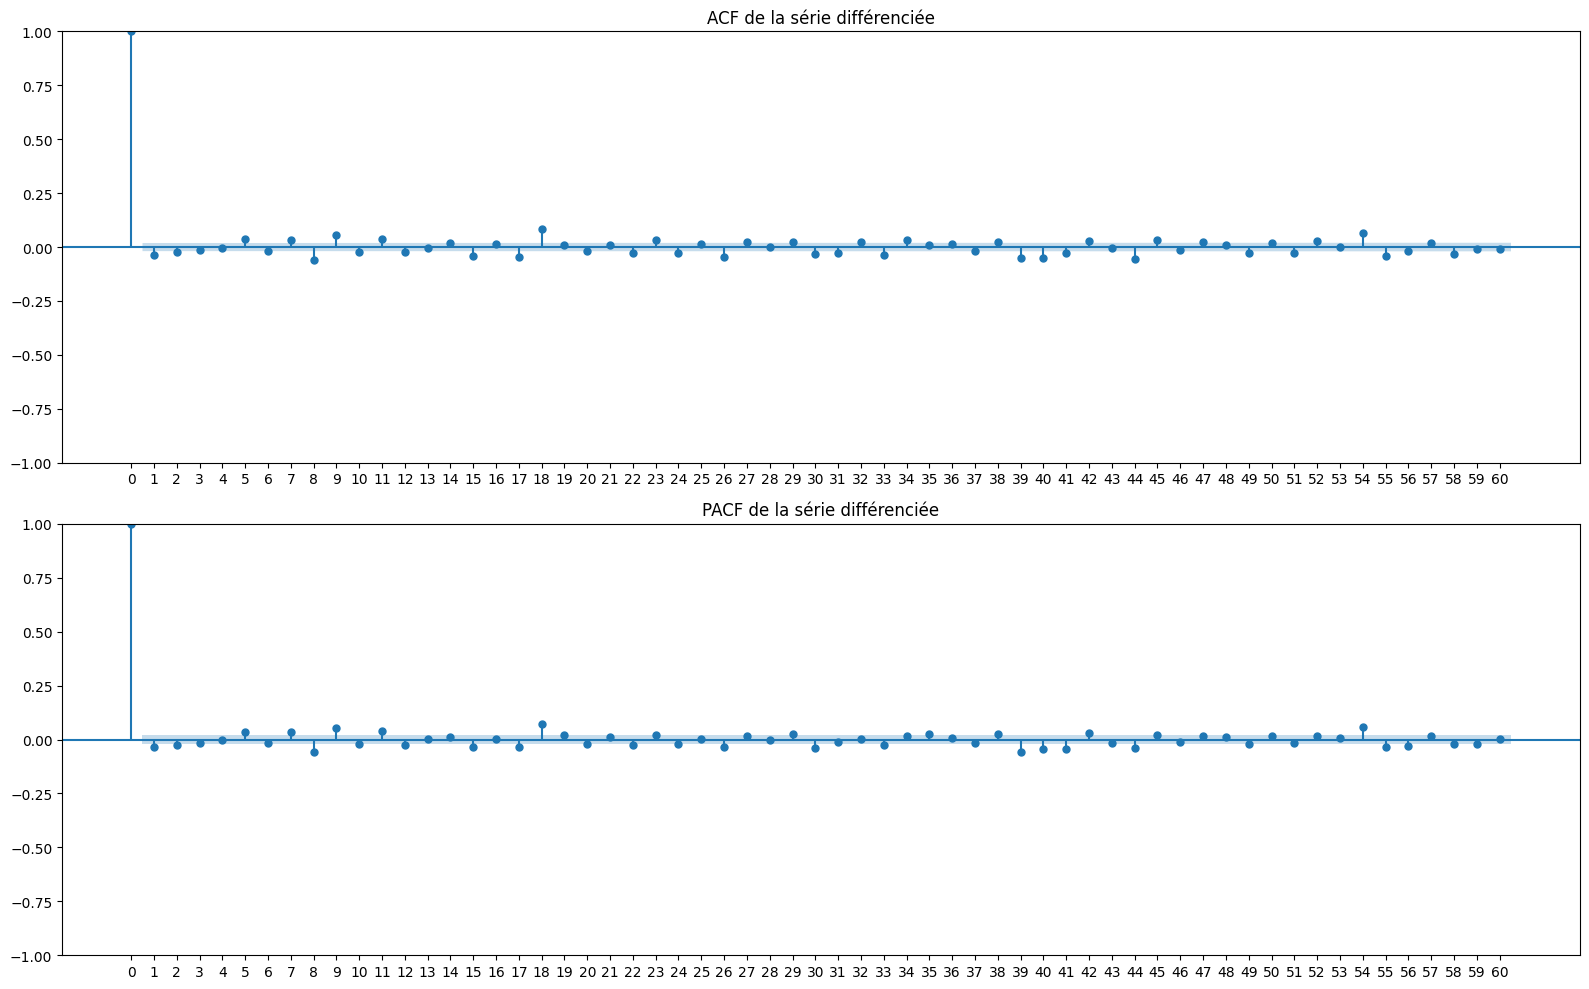

In [43]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- ACF ---

plot_acf(data_diff, ax=ax1, lags=60)
ax1.set_title("ACF de la série différenciée")
ax1.set_xticks(range(0, 61, 1))

# --- PACF ---

plot_pacf(data_diff, ax=ax2, lags=60, method='ywm')
ax2.set_title("PACF de la série différenciée")
ax2.set_xticks(range(0, 61, 1))

plt.tight_layout()
plt.show()

Interprétations des graphiques ACF et PACF de la série différenciée pour estimer les ordres p et q :

1. Graphique ACF (Autocorrélation) de la série différenciée :

Nous observons un pic significatif et positif au décalage 1 (lag 1).
Après le décalage 1, les autocorrélations diminuent rapidement et restent majoritairement à l'intérieur des intervalles de confiance (les zones bleues).

Interprétation pour q (ordre MA) : Une chute nette après le premier décalage significatif dans l'ACF suggère un ordre de moyenne mobile (MA) de q = 1.

2. Graphique PACF (Autocorrélation Partielle) de la série différenciée :

Similairement à l'ACF, nous constatons un pic significatif et positif au décalage 1 (lag 1).
Après le décalage 1, les autocorrélation partielles diminuent également rapidement et restent en grande partie dans les intervalles de confiance.
Interprétation pour p (ordre AR) : Une chute nette après le premier décalage significatif dans le PACF suggère un ordre auto-régressif (AR) de p = 1.
En résumé :

Puisque la série a été différenciée une fois pour la rendre stationnaire, l'ordre de différenciation d est de 1.
Les analyses ACF et PACF de la série différenciée suggèrent que les ordres auto-régressifs p et de moyenne mobile q sont tous deux de 1.
Cela nous mène à considérer un modèle ARIMA(1,1,1) comme un bon point de départ pour la modélisation de cette série temporelle.

## Appliquer les moyennes mobiles pour lisser la série

La moyenne mobile consiste à remplacer chaque point de la série par la moyenne des n points précédents.


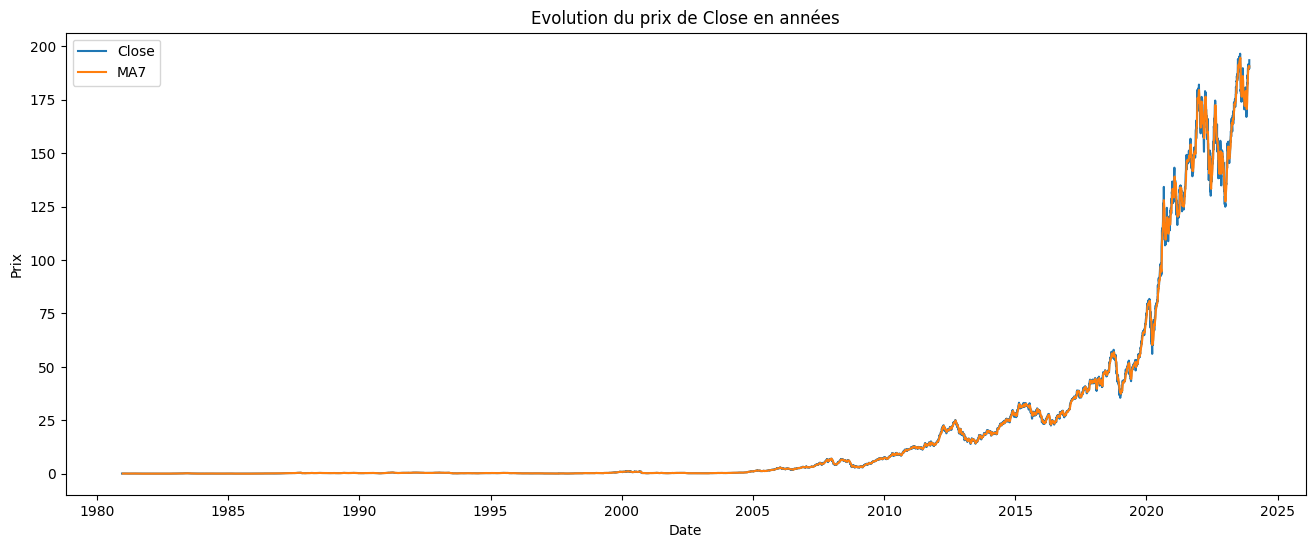

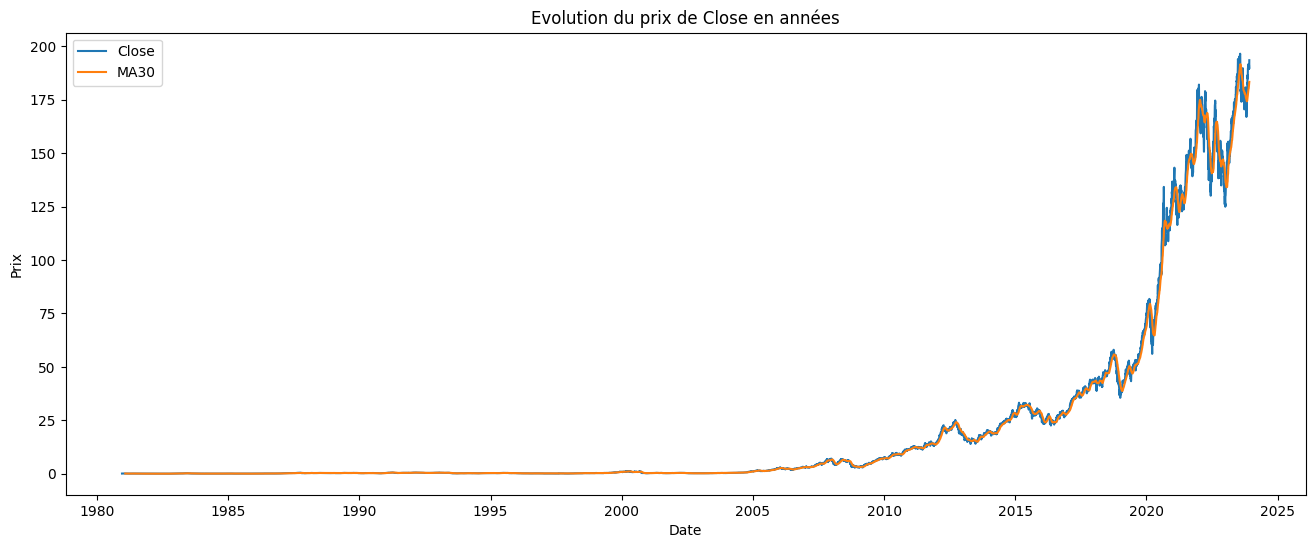

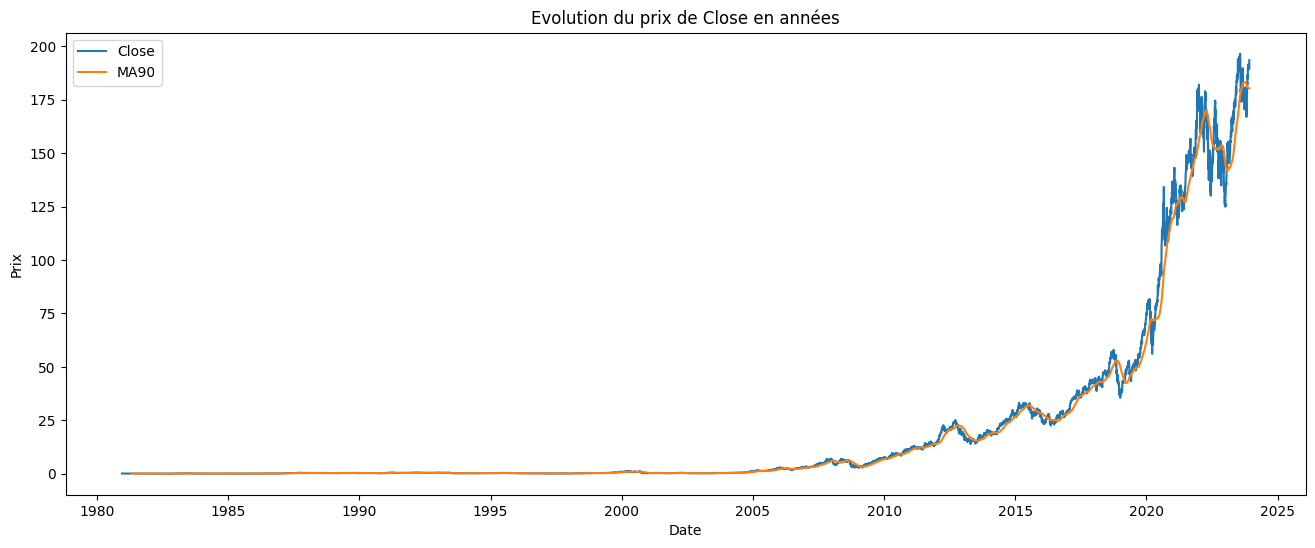

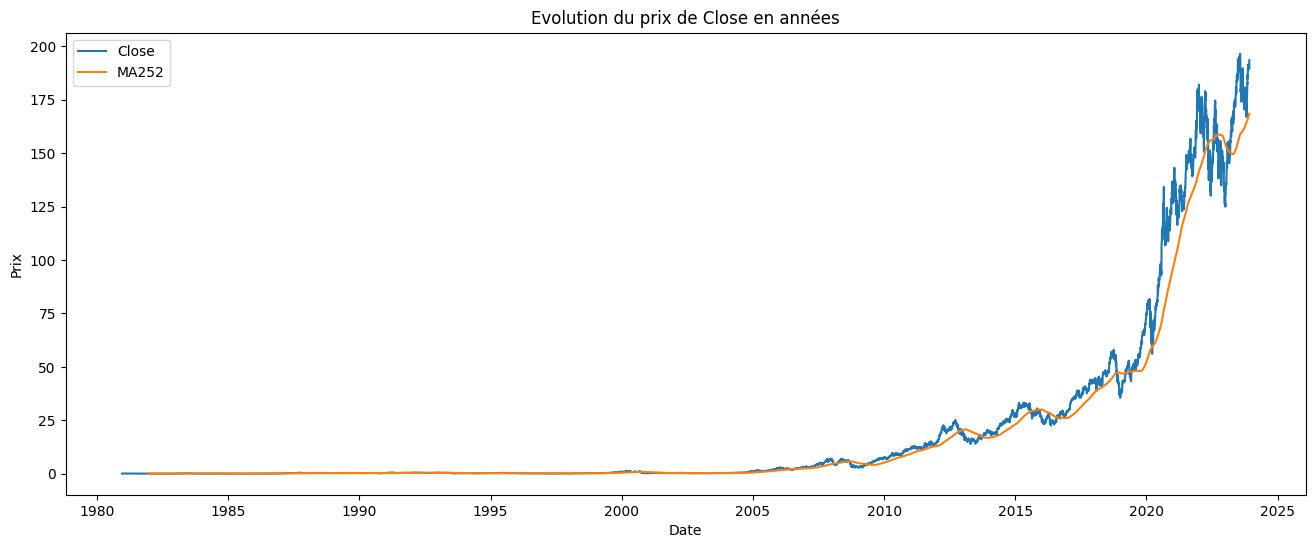

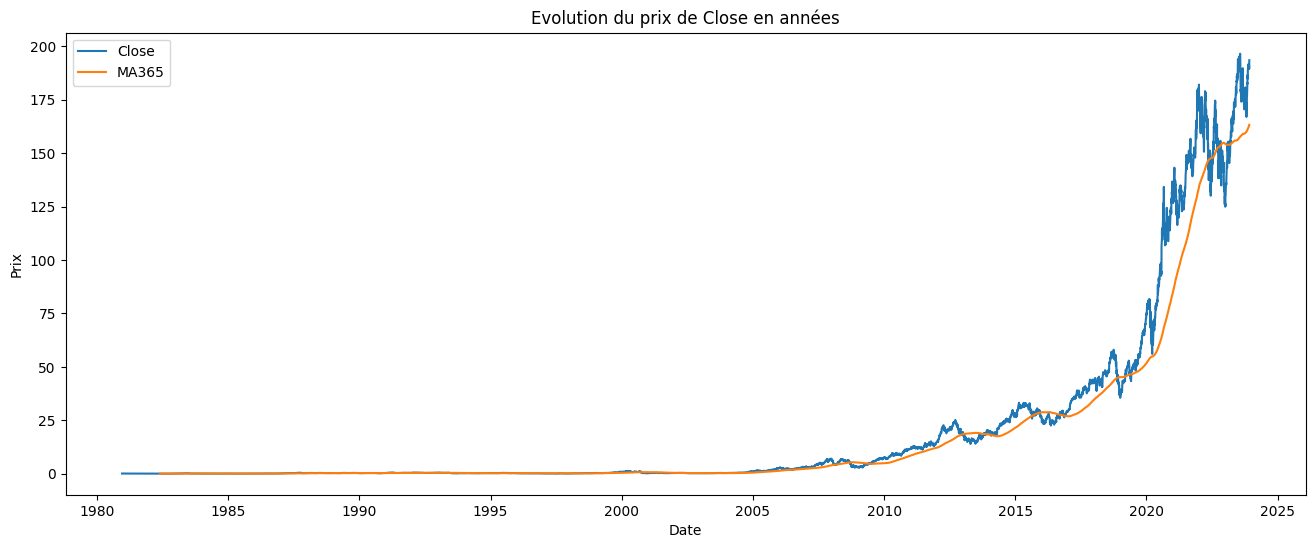

In [18]:
# appliquer les moyennes mobiles a différents temps
for w in [7,30,90,252,365]:
  data[f'MA{w}'] = data['Close'].rolling(window=w).mean()
  plt.figure(figsize=(16,6))
  plt.plot(data.index, data['Close'], label='Close')
  plt.plot(data.index, data[f'MA{w}'], label=f'MA{w}')
  plt.xlabel('Date')
  plt.ylabel('Prix')
  plt.title(f'Evolution du prix de {data_diff.name} en années')
  plt.legend()
  plt.show()


Nous avons tracé plusieurs moyennes mobiles (MA) pour la série des prix de clôture ('Close') avec différentes fenêtres (7, 30, 90, 252, 365 jours). Voici l'interprétation générale :

***Lissage des Données*** : L'objectif principal d'une moyenne mobile est de lisser les fluctuations à court terme des prix pour mieux visualiser la tendance sous-jacente. Plus la fenêtre de la moyenne mobile est grande (par exemple, 365 jours), plus le lissage est important.

- MA7 (Moyenne Mobile sur 7 jours) : C'est une moyenne mobile très réactive. Elle suit de près les mouvements de prix quotidiens et est utilisée pour identifier les tendances à très court terme ou les changements rapides. Elle lisse un peu le bruit quotidien, mais reste très proche du prix original.

- MA30 (Moyenne Mobile sur 30 jours) : Cette moyenne mobile est plus lisse que la MA7 et est souvent utilisée pour observer les tendances à court terme à moyen terme. Elle filtre davantage le bruit et donne une meilleure indication de la direction du prix sur un mois.

- MA90 (Moyenne Mobile sur 90 jours) : Représente une tendance sur trois mois. Elle est encore plus lisse et est utile pour identifier les tendances intermédiaires, offrant une perspective plus stable de l'évolution des prix sur un trimestre.

- MA252 (Moyenne Mobile sur 252 jours) : Cette moyenne mobile correspond approximativement à une année de jours de bourse. C'est une moyenne très importante pour identifier les tendances à long terme. Elle est beaucoup plus lisse et permet de voir la direction générale du marché sur une période d'un an, en ignorant les fluctuations mineures.

- MA365 (Moyenne Mobile sur 365 jours) : Semblable à la MA252, elle offre une vue sur la tendance annuelle ou même pluriannuelle en incluant tous les jours calendaires. C'est un indicateur de tendance à très long terme, très lissé et lent à réagir aux changements récents.

En résumé : À mesure que la période de la moyenne mobile augmente, la ligne devient plus lisse et moins sensible aux variations de prix récentes, se concentrant sur la tendance de fond. Les moyennes mobiles plus courtes sont plus volatiles et montrent des tendances à court terme, tandis que les moyennes plus longues révèlent les tendances dominantes sur de plus longues périodes. Elles confirment visuellement la forte tendance haussière déjà observée dans la série des prix 'Close'.



## Désaisonnaliser avec régression linéaire et moyennes mobiles.

### Task
Calculate the 252-day moving average of the 'Close' price and then subtract it from the original 'Close' price series to detrend it.

### Calculate Moving Average for Trend

### Subtask:
Calculate a 252-day moving average of the 'Close' price to estimate the trend component.


**Reasoning**:
The subtask requires calculating the 252-day moving average of the 'Close' price. The `data` DataFrame already exists and contains the 'Close' column. I will use the `rolling()` and `mean()` methods to compute this and store it in a new column named 'MA252'.



In [20]:
data['MA252'] = data['Close'].rolling(window=252).mean()
print("252-day moving average calculated and stored in 'MA252' column.")


252-day moving average calculated and stored in 'MA252' column.


### Detrend the Series

### Subtask:
Subtract the calculated moving average (trend component) from the original 'Close' price series to obtain a detrended series.


**Reasoning**:
To detrend the 'Close' series, I will subtract the 'MA252' (moving average trend component) from it and store the result in a new column called 'detrended_close'. Then, I will display the head of the dataframe to check the new column and drop any rows with NaN values in 'detrended_close' to handle the missing values introduced by the rolling mean.



In [22]:
data['detrended_close'] = data['Close'] - data['MA252']
data.dropna(subset=['detrended_close'], inplace=True)
print("Detrended 'Close' series created and NaN values handled.")
data.head()

Detrended 'Close' series created and NaN values handled.


,Open,High,Low,Close,Adj Close,Volume,MA7,MA30,MA90,MA252,MA365,detrended_close
Date,,,,,,,,,,,,
1981-12-10,0.084263,0.084821,0.084263,0.084263,0.065205,37408000,0.084104,0.083798,0.085931,0.110797,NaN,-0.026534
1981-12-11,0.084263,0.084821,0.083705,0.083705,0.064773,76092800,0.084104,0.083649,0.085578,0.110619,NaN,-0.026914
1981-12-14,0.082031,0.082031,0.080915,0.080915,0.062614,25244800,0.083864,0.083370,0.085224,0.110458,NaN,-0.029543
1981-12-15,0.083147,0.083705,0.083147,0.083147,0.064341,31315200,0.083625,0.083166,0.084896,0.110340,NaN,-0.027193
1981-12-16,0.087054,0.087612,0.087054,0.087054,0.067364,65452800,0.083865,0.083129,0.084611,0.110228,NaN,-0.023174


**Reasoning**:
Now that the series has been detrended, it's important to visualize the 'detrended_close' series to confirm the removal of the long-term trend and observe its characteristics. This visual inspection will help in understanding the remaining patterns, such as seasonality or stationarity.



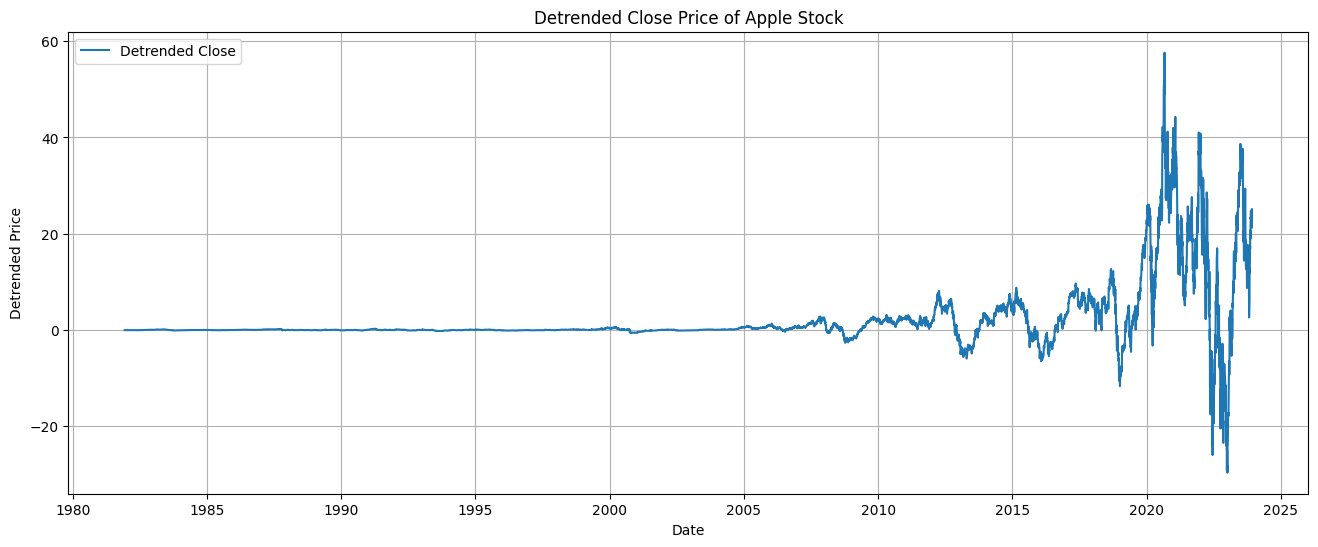

In [23]:
plt.figure(figsize=(16,6))
plt.plot(data.index, data['detrended_close'], label='Detrended Close')
plt.xlabel('Date')
plt.ylabel('Detrended Price')
plt.title('Detrended Close Price of Apple Stock')
plt.legend()
plt.grid(True)
plt.show()


### Calculate Seasonal Component

### Subtask:
For the detrended series, calculate the average value for each specific period within a season (e.g., average for each day of the year) to estimate the seasonal component.


**Reasoning**:
To calculate the seasonal component, I will first extract the 'day_of_year' from the 'Date' index of the 'data' DataFrame. Then, I will group the 'data' DataFrame by 'day_of_year' and calculate the mean of 'detrended_close' for each day.



In [24]:
data['day_of_year'] = data.index.day_of_year
seasonal_component = data.groupby('day_of_year')['detrended_close'].mean()
print("Seasonal component calculated:")
print(seasonal_component.head())

Seasonal component calculated:
day_of_year
2    1.273878
3    1.308968
4    1.523454
5    1.816192
6    2.270506
Name: detrended_close, dtype: float64


In [25]:
data['seasonal_effect'] = data['day_of_year'].map(seasonal_component)
data['deseasonalized_close'] = data['detrended_close'] - data['seasonal_effect']

print("Deseasonalized 'Close' series created.")
display(data.head())

Deseasonalized 'Close' series created.


,Open,High,Low,Close,Adj Close,Volume,MA7,MA30,MA90,MA252,MA365,detrended_close,day_of_year,seasonal_effect,deseasonalized_close
Date,,,,,,,,,,,,,,,
1981-12-10,0.084263,0.084821,0.084263,0.084263,0.065205,37408000,0.084104,0.083798,0.085931,0.110797,NaN,-0.026534,344,3.298779,-3.325312
1981-12-11,0.084263,0.084821,0.083705,0.083705,0.064773,76092800,0.084104,0.083649,0.085578,0.110619,NaN,-0.026914,345,2.015172,-2.042087
1981-12-14,0.082031,0.082031,0.080915,0.080915,0.062614,25244800,0.083864,0.083370,0.085224,0.110458,NaN,-0.029543,348,1.013580,-1.043122
1981-12-15,0.083147,0.083705,0.083147,0.083147,0.064341,31315200,0.083625,0.083166,0.084896,0.110340,NaN,-0.027193,349,2.090368,-2.117562
1981-12-16,0.087054,0.087612,0.087054,0.087054,0.067364,65452800,0.083865,0.083129,0.084611,0.110228,NaN,-0.023174,350,2.490596,-2.513770


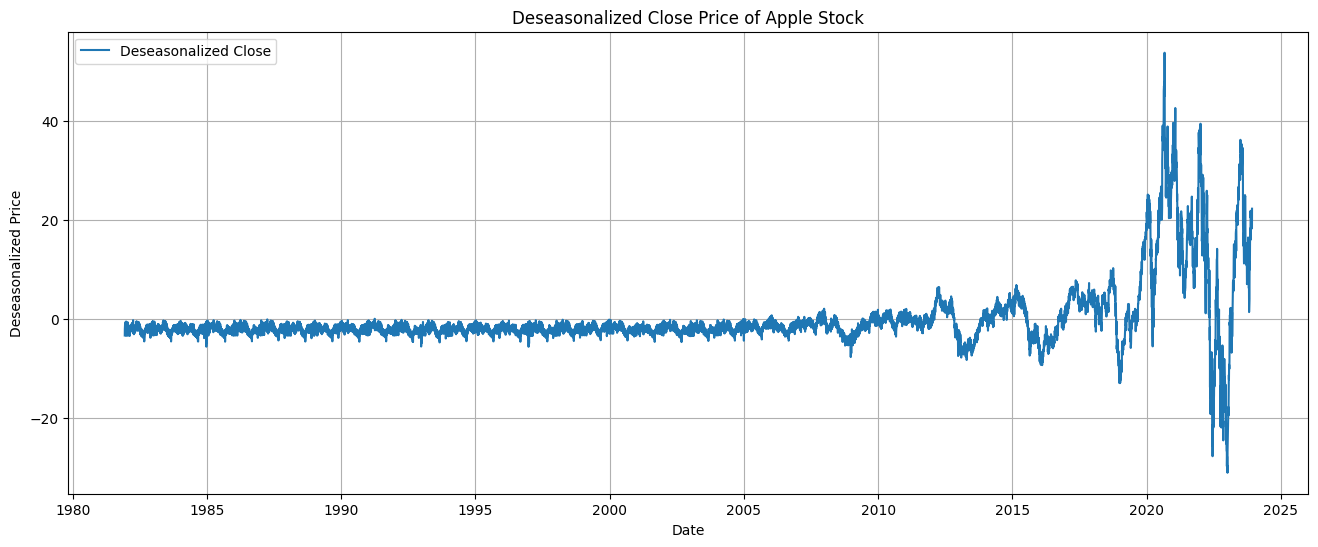

In [26]:
plt.figure(figsize=(16,6))
plt.plot(data.index, data['deseasonalized_close'], label='Deseasonalized Close')
plt.xlabel('Date')
plt.ylabel('Deseasonalized Price')
plt.title('Deseasonalized Close Price of Apple Stock')
plt.legend()
plt.grid(True)
plt.show()

### Deseasonalize the Series

### Subtask:
Subtract the estimated seasonal component from the original 'Close' price series to obtain the deseasonalized series.


### Summary:

### Data Analysis Key Findings
*   A 252-day moving average (long-term trend) was successfully calculated and stored in a new column named `MA252`.
*   The original 'Close' price series was detrended by subtracting its 252-day moving average, creating a new series called `detrended_close`. Rows with missing values (due to the moving average calculation) were removed.
*   A seasonal component was identified by calculating the average `detrended_close` for each day of the year. For example, the average detrended price for day 2 was approximately 1.27 and for day 3 was approximately 1.31.




# Approche lissage exponentiel

## Lissage exponentiel simple avec la Méthode de Holt-Winters pour intégrer la saisonnalité.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


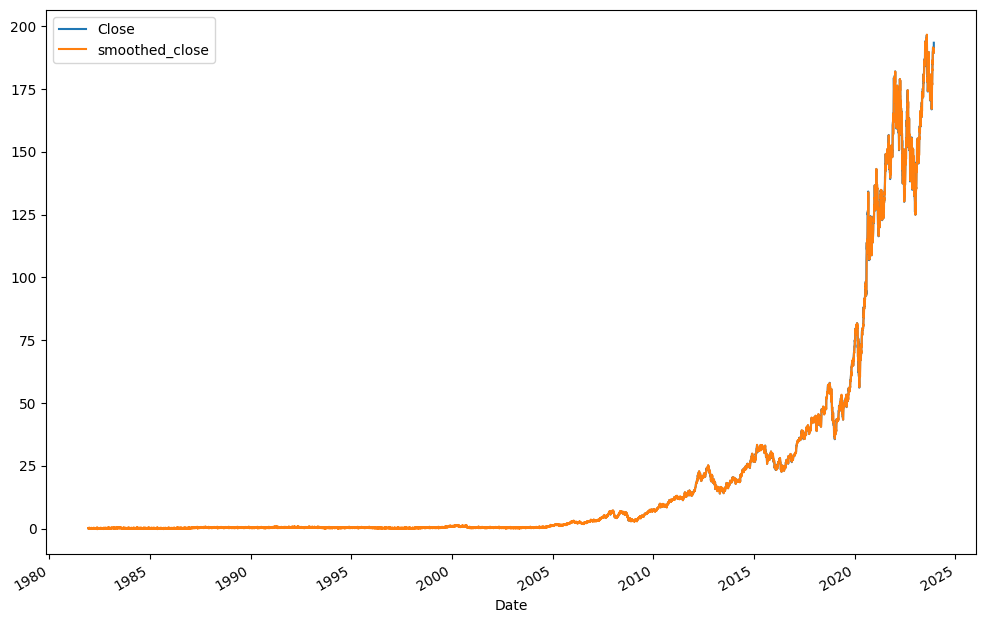

In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(data['Close'], seasonal_periods=252, trend='add', seasonal='add').fit()
data['smoothed_close'] = model.fittedvalues
data[['Close', 'smoothed_close']].plot(figsize=(12, 8))
plt.show()

interprétation du lissage exponentiel avec la méthode de Holt-Winters pour intégrer à la saisonnalité.

1. Ce que fait la méthode de Holt-Winters (avec trend='add', seasonal='add') :

Elle modélise une tendance additive : la série a une tendance linéaire qui augmente ou diminue à un taux constant.
Elle modélise une saisonnalité additive : la saisonnalité se répète avec une amplitude constante au fil du temps. La period=252 indique que la saisonnalité est annuelle, basée sur les jours de bourse.
Elle utilise des poids exponentiellement décroissants pour les observations passées, donnant plus d'importance aux données récentes.

2. Interprétation de la figure data[['Close', 'smoothed_close']].plot(...) :

La courbe smoothed_close représente la série originale Close, mais avec les composantes de tendance et de saisonnalité estimées et lissées par le modèle.
Vous devriez observer que la ligne smoothed_close suit de près la ligne Close d'origine, mais avec beaucoup moins de volatilité et de bruit. Elle met en évidence la tendance sous-jacente et les cycles saisonniers que le modèle a identifiés.
La capacité du modèle à capturer la saisonnalité est cruciale pour des prédictions plus précises. Ici, avec un seasonal_periods=252, le modèle tente d'apprendre les schémas qui se répètent chaque année de jours de bourse.


# Approche ARIMA/SARIMA

## Identifier les paramètres optimaux (p, d, q).

Méthode 1 : approche graphique: le pacf et l'acf nous a montré que p=1, q= 1, d=1 ce qui veut dire qu'on va entrainer un modéle ARIMA(1,1,1)

## Entrainer le modéle ARIMA

In [46]:
# Séparer notre jeu de donnée en base de test et de train
train_data = data_diff[:-252]
test_data = data_diff[-252:]

### Estimations du modéle

In [47]:
from statsmodels.tsa.arima.model import ARIMA
# créer un modéle ARIMA(1,1,1)
model = ARIMA(train_data, order=(1,1,1))
# Ajuster le modéle

result = model.fit()

# afficher le resultat du modéle
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                10583
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12298.399
Date:                Sun, 23 Nov 2025   AIC                          24602.798
Time:                        12:23:09   BIC                          24624.599
Sample:                             0   HQIC                         24610.157
                              - 10583                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0603      0.002    -25.124      0.000      -0.065      -0.056
ma.L1         -0.9993      0.000  -7313.280      0.000      -1.000      -0.999
sigma2         0.5980      0.002    364.228      0.0

### Vérification du modéle

Interprétation du résultat de l'entraînement du modèle ARIMA(1,1,1) sur la série différenciée :


2. Coefficients des Termes (ar.L1, ma.L1) :

ar.L1 (terme auto-régressif à l'ordre 1) : Son coefficient est de -0.0603 et sa p-value est de 0.000. Une p-value inférieure à 0.05 indique que ce terme est statistiquement significatif. La valeur négative suggère une légère corrélation négative avec la valeur précédente.  

ma.L1 (terme de moyenne mobile à l'ordre 1) : Son coefficient est de -0.9993 et sa p-value est de 0.000. Ce terme est également très significatif. Une valeur de MA(1) très proche de -1 est parfois un signe d'une possible sur-différenciation ou que le processus MA est très fort, presque une racine unitaire. Cela mérite une attention particulière si le modèle ne performe pas bien.

sigma2 (variance des résidus) : Sa valeur est de 0.5980 et est également très significative.

3. Tests de Diagnostic des Résidus :

Test de Ljung-Box (Q) : Prob(Q) = 0.83. C'est une excellente nouvelle ! Une p-value élevée (supérieure à 0.05) pour ce test signifie que nous ne pouvons pas rejeter l'hypothèse nulle selon laquelle les résidus du modèle sont des bruits blancs (c'est-à-dire qu'ils ne contiennent pas d'autocorrélation significative). Cela indique que votre modèle a bien capturé les dépendances linéaires dans la série temporelle.  

Test de Jarque-Bera (JB) : Prob(JB) = 0.00. Une p-value très faible (inférieure à 0.05) indique que les résidus ne sont pas normalement distribués. C'est très fréquent avec les données financières (les rendements boursiers ont souvent des distributions à queues épaisses et asymétriques, ce qu'indiquent aussi le Skew de 0.01 et le Kurtosis de 52.77, très élevé).

Test d'Hétéroscédasticité (H) : Prob(H) = 0.00. Une p-value très faible signifie que nous rejetons l'hypothèse d'homoscédasticité. Les résidus présentent donc une hétéroscédasticité, ce qui veut dire que leur variance n'est pas constante au fil du temps. C'est également très courant dans les séries financières et est souvent le signe de phénomènes comme la volatilité en clusters (effets GARCH).

En résumé : notre modèle ARIMA(1,1,1) a fait un très bon travail en capturant la structure d'autocorrélation de la série (les résidus sont des bruits blancs). C'est le but principal d'un modèle ARIMA. Cependant, comme souvent avec les données boursières, les résidus ne sont pas normalement distribués et présentent une hétéroscédasticité. Pour de la prévision simple, ce modèle peut être adéquat. Si la modélisation de la volatilité est cruciale, vous pourriez envisager des modèles plus avancés comme les modèles GARCH (Generalized Autoregressive Conditional Heteroskedasticity) pour mieux gérer l'hétéroscédasticité des résidus.

les residus sont normalement distribués cela peut se confirmer avec le test de Jack berra issu du resultat.


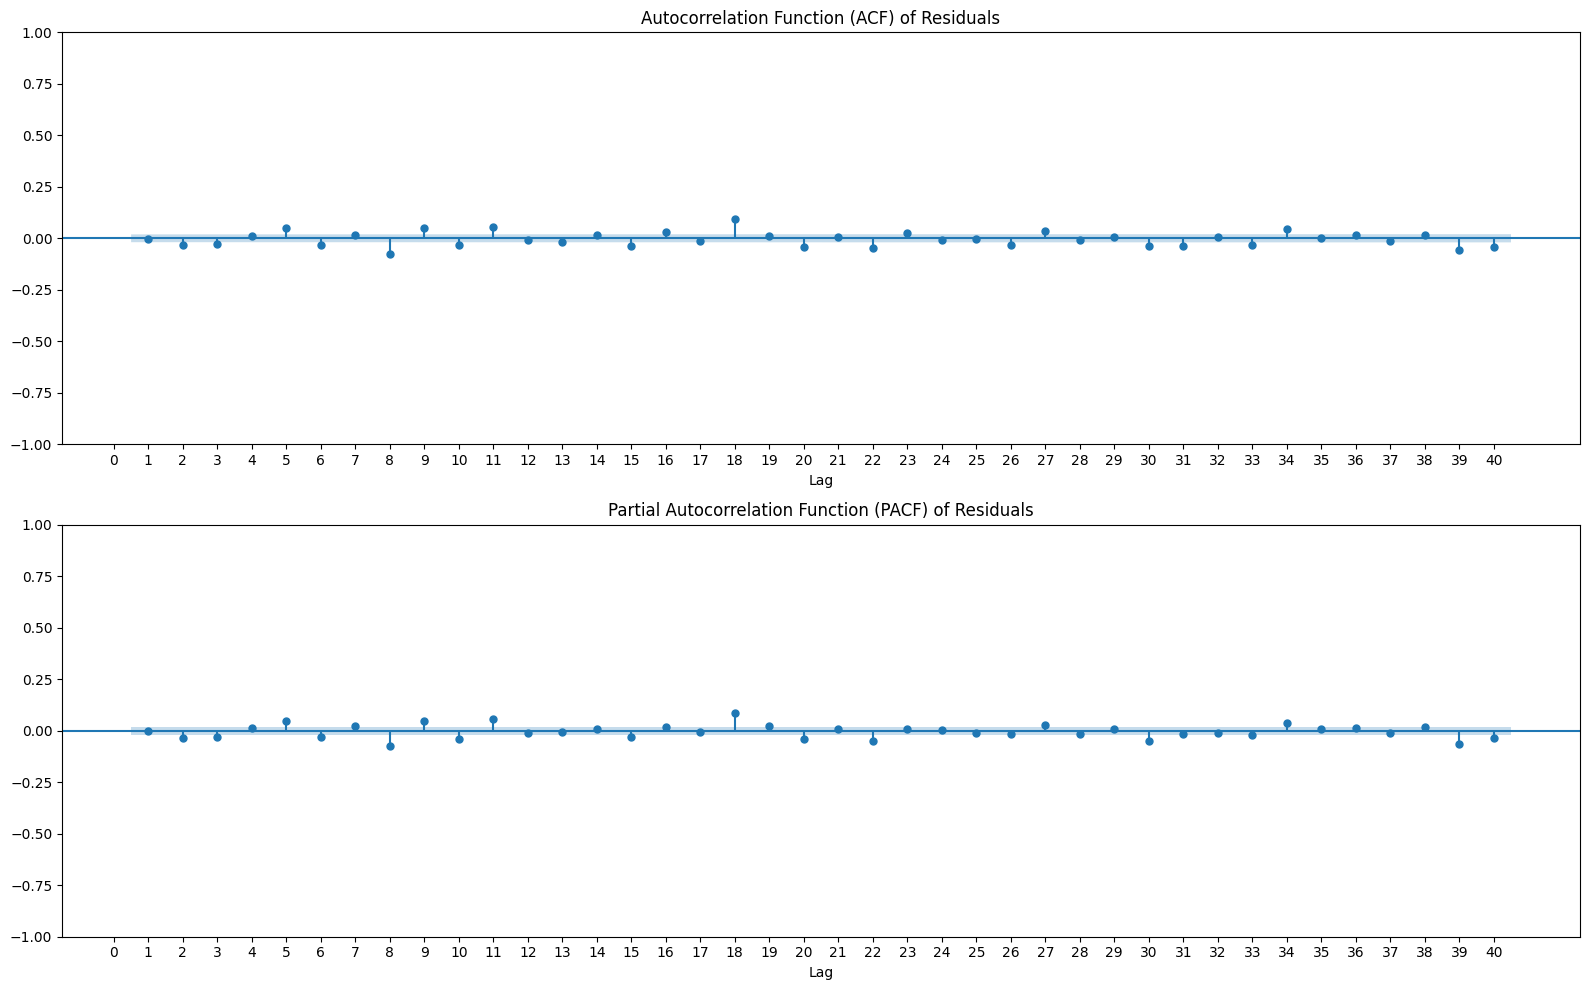

In [56]:
# Afficher l'acf et le pacf des résidus
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# calculer les résidus
residuals = result.resid

# tracer l'acf des résidus
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(residuals, lags=40, zero=False, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) of Residuals')
ax1.set_xticks(range(0, 41, 1))
ax1.set_xlabel('Lag')


# tracer le pacf des résidus
plot_pacf(residuals, lags=40, zero=False, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) of Residuals')
ax2.set_xticks(range(0, 41, 1))
ax2.set_xlabel('Lag')

plt.tight_layout()
plt.show()

Les résidus sont les bruits blanc car les pics se retrouvent dans les bornes.

## Prédictions

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


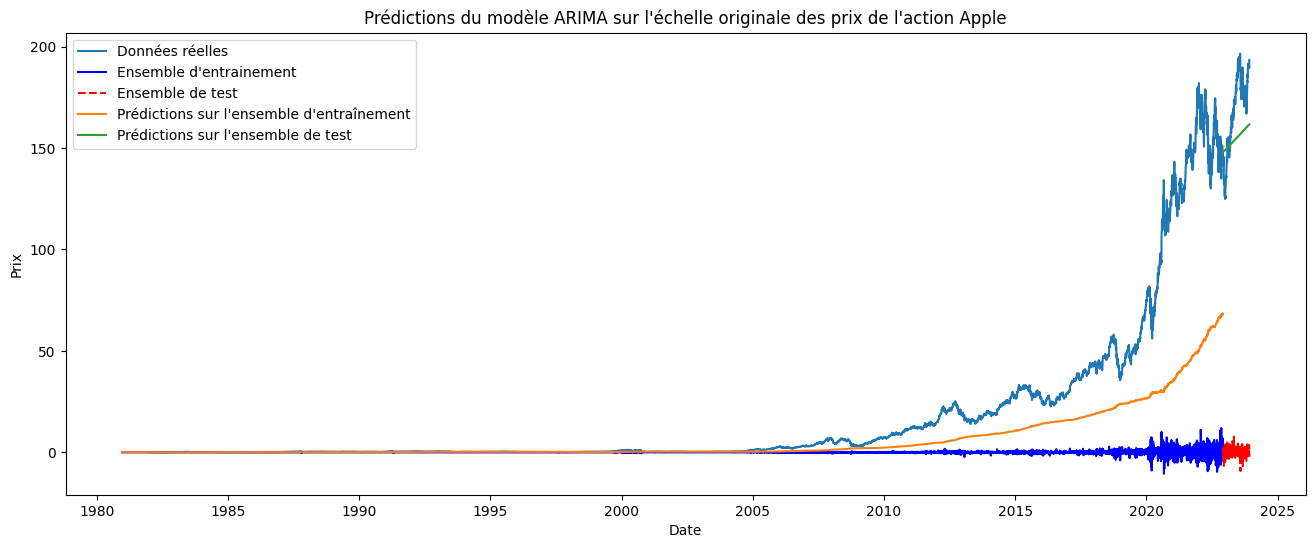

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prédictions sur l'ensemble d'entraînement (ces sont des valeurs différenciées)
train_prediction_diff = result.fittedvalues

# Prédictions sur la base test (ce sont des valeurs différenciées)
test_prediction_diff = result.forecast(steps=len(test_data))
test_prediction_diff.index = test_data.index # Assigner l'index pour un alignement correct

# Inverse differencing pour ramener les prédictions à l'échelle originale du prix 'Close'

# Pour les prédictions d'entraînement, nous avons besoin de la valeur initiale de 'Close'
# qui correspond au point juste avant le début de data_diff.
# data_diff commence à data.index[1], donc la valeur de départ est data['Close'].iloc[0].
initial_close_for_train_diff = data['Close'].iloc[0]

train_prediction_original_scale = initial_close_for_train_diff + train_prediction_diff.cumsum().reindex(train_data.index, fill_value=0)

# Pour les prédictions de test, le point de départ pour l'inverse differencing est
# la dernière valeur réelle de 'Close' avant le début de la période de test.
last_actual_close_before_test = data['Close'].loc[train_data.index[-1]]

test_prediction_original_scale = last_actual_close_before_test + test_prediction_diff.cumsum()

# Tracer les prédictions et les données réelles avec la courbe
plt.figure(figsize=(16, 6))
plt.plot(data.index, data['Close'], label='Données réelles')
plt.plot(train_data.index, train_data.values, label='Ensemble d\'entrainement', color ='blue' )
plt.plot(test_data.index, test_data.values, label='Ensemble de test', color = 'red', linestyle = '--')

plt.plot(train_prediction_original_scale.index, train_prediction_original_scale, label='Prédictions sur l\'ensemble d\'entraînement')
plt.plot(test_prediction_original_scale.index, test_prediction_original_scale, label='Prédictions sur l\'ensemble de test')
plt.xlabel('Date')
plt.ylabel('Prix')
plt.title('Prédictions du modèle ARIMA sur l\'échelle originale des prix de l\'action Apple')
plt.legend()
plt.show()

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# mésurer les performances sur l'ensemble d'entrainement (série différenciée)
train_mae = mean_absolute_error(train_data, train_prediction_diff)
train_mse = mean_squared_error(train_data, train_prediction_diff)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(train_data, train_prediction_diff)

print(f"Performances sur l'ensemble d'entraînement (série différenciée) :")
print(f"MAE : {train_mae}")
print(f"MSE : {train_mse}")
print(f"RMSE : {train_rmse}")
print(f"R2 : {train_r2}")

# mésurer les performances sur l'ensemble de test (série différenciée)
test_mae = mean_absolute_error(test_data, test_prediction_diff)
test_mse = mean_squared_error(test_data, test_prediction_diff)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(test_data, test_prediction_diff)

print(f"\nPerformances sur l'ensemble de test (série différenciée) :")
print(f"MAE : {test_mae}")
print(f"MSE : {test_mse}")
print(f"RMSE : {test_rmse}")
print(f"R2 : {test_r2}")

# créer un dataframe pour afficher les resultats
results_df = pd.DataFrame({
    'Ensemble': ['Train', 'Test'],
    'MAE': [train_mae, test_mae],
    'MSE': [train_mse, test_mse],
    'RMSE': [train_rmse, test_rmse],
    'R2': [train_r2, test_r2]
})

results_df

Performances sur l'ensemble d'entraînement (série différenciée) :
MAE : 0.23114217853434868
MSE : 0.5979784975374287
RMSE : 0.7732906940714007
R2 : 0.003726650279528898

Performances sur l'ensemble de test (série différenciée) :
MAE : 1.7290892598251042
MSE : 4.985682677079462
RMSE : 2.232864231671837
R2 : -0.0032720413049893704


,Ensemble,MAE,MSE,RMSE,R2
0,Train,0.231142,0.597978,0.773291,0.003727
1,Test,1.729089,4.985683,2.232864,-0.003272


interprétons des métriques du modèle ARIMA, qui a été entraîné sur la série différenciée.

Voici les résultats :

MAE, MSE, RMSE (Erreurs absolues et quadratiques) :

Sur l'entraînement, les erreurs sont relativement faibles (MAE ~0.23, RMSE ~0.77). Cela indique que le modèle parvient à s'adapter aux changements de prix quotidiens (la série différenciée) sur les données qu'il a déjà vues.
Sur le test, les erreurs sont plus élevées (MAE ~1.73, RMSE ~2.23) que sur l'entraînement. Cela signifie que le modèle a plus de difficultés à prédire ces changements sur de nouvelles données. Cependant, ces valeurs représentent des erreurs sur les changements de prix, et non sur les prix absolus, donc elles doivent être interprétées en conséquence.

R2 (Coefficient de Détermination) :

Sur l'entraînement (R2 = 0.0037) : Un R2 très proche de zéro indique que le modèle explique une part infime de la variance des changements de prix sur l'ensemble d'entraînement. En d'autres termes, même sur les données d'apprentissage, le modèle a du mal à capturer de manière significative les mouvements de la série différenciée.
Sur le test (R2 = -0.0032) : Un R2 négatif, même s'il est très faible, est un indicateur important. Il signifie que votre modèle est légèrement moins performant que si vous aviez simplement prédit la moyenne des changements de prix sur l'ensemble de test. Pour les prévisions de changements de prix boursiers, un R2 faible (proche de zéro) est malheureusement très courant, car la volatilité est intrinsèque et difficilement modélisable avec des modèles linéaires.
En résumé : Votre modèle ARIMA(1,1,1) a une très faible capacité à prédire les changements quotidiens des prix de l'action Apple. Bien que les tests diagnostiques des résidus aient montré un bruit blanc (ce qui est bon pour la validité statistique du modèle ARIMA), les métriques de performance indiquent que le modèle n'explique qu'une fraction négligeable de la variance des changements de prix. Cela souligne la difficulté de prévoir des séries financières volatiles avec des modèles linéaires comme ARIMA. Le modèle ne fournit pas de prédictions suffisamment précises ou informatives pour être utile dans un contexte d'investissement où les changements quotidiens sont cruciaux.



### tracer les prédictions sur la série différenciée

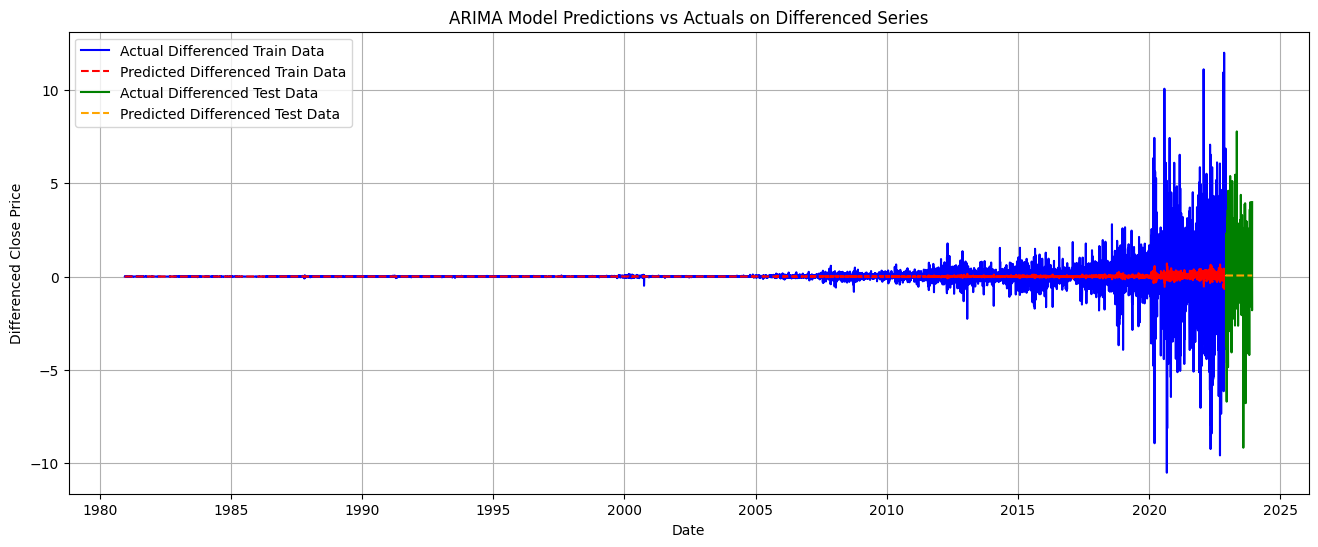

In [65]:
plt.figure(figsize=(16, 6))
plt.plot(train_data.index, train_data, label='Actual Differenced Train Data', color='blue')
plt.plot(train_prediction_diff.index, train_prediction_diff, label='Predicted Differenced Train Data', color='red', linestyle='--')
plt.plot(test_data.index, test_data, label='Actual Differenced Test Data', color='green')
plt.plot(test_prediction_diff.index, test_prediction_diff, label='Predicted Differenced Test Data', color='orange', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.title('ARIMA Model Predictions vs Actuals on Differenced Series')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion

Synthèse du Processus :

Préparation des Données : Nous avons chargé les données historiques des prix de l'action Apple, converti la colonne 'Date' au format datetime et l'avons définie comme index. Nous avons vérifié l'absence de valeurs manquantes ou de doublons.
Analyse Exploratoire : L'analyse graphique a révélé une forte tendance haussière dans les prix de clôture. La décomposition saisonnière et l'analyse ACF/PACF sur la série brute ont confirmé cette tendance et la non-stationnarité, sans saisonnalité prononcée.
Stationnarité : Pour rendre la série stationnaire, nous avons appliqué une différenciation d'ordre 1. Les tests ADF ont fortement confirmé la stationnarité de la série différenciée, bien que le test KPSS ait émis une réserve, fréquente avec des données financières. L'ACF et le PACF de la série différenciée ont ensuite suggéré un modèle ARIMA(1,1,1).
Modélisation ARIMA : Un modèle ARIMA(1,1,1) a été entraîné sur la série différenciée. Les diagnostics du modèle ont montré que les résidus étaient du bruit blanc (confirmé par le test de Ljung-Box et les plots ACF/PACF des résidus), ce qui indique que le modèle a bien capturé les dépendances linéaires. Cependant, les résidus n'étaient pas normalement distribués et présentaient de l'hétéroscédasticité, typique des données financières.
Évaluation et Prédictions : Les prédictions ont été réalisées et comparées aux données réelles, après avoir ramené les prédictions à l'échelle originale des prix. L'évaluation des métriques (MAE, MSE, RMSE, R2) sur la série différenciée a montré des résultats très faibles, avec un R2 proche de zéro (ou négatif sur le test). Visuellement, le modèle n'a pas réussi à capturer la dynamique volatile des changements de prix.
Conclusion Générale :

Le modèle ARIMA(1,1,1), bien qu'il ait réussi à rendre les résidus 'blancs' (une exigence fondamentale), s'est avéré inefficace pour la prévision des prix de l'action Apple. Les métriques de performance sur la série différenciée, en particulier le R2 très faible, indiquent que le modèle explique une part négligeable de la variance des changements de prix et ne fait guère mieux qu'une prédiction basée sur la moyenne. Cette limitation est courante avec les modèles linéaires comme ARIMA face à la complexité, la non-linéarité et la forte volatilité inhérentes aux données boursières.

Pour des prévisions plus fiables sur les marchés financiers, il serait nécessaire d'explorer des approches plus sophistiquées, telles que :

Modèles SARIMA : Pour une éventuelle saisonnalité qui n'aurait pas été clairement identifiée ou capturée.
Modèles GARCH : Pour modéliser l'hétéroscédasticité (la volatilité variable) des résidus, cruciale en finance.
Modèles de Machine Learning ou Deep Learning : (comme les réseaux de neurones récurrents - LSTMs) qui sont mieux adaptés pour capturer les relations non-linéaires et les dépendances à long terme dans les séries temporelles complexes.
Intégration de variables exogènes : (nouvelles, indices boursiers, actualités économiques) qui peuvent influencer les prix.
En résumé, l'analyse a montré que si l'ARIMA peut valider certaines hypothèses statistiques, sa capacité prédictive sur ce jeu de données est très limitée, soulignant la difficulté intrinsèque de prévoir les mouvements des actions avec des modèles traditionnels.

